Quantitative Analysis using PyNance and TA-Lib

This script performs comprehensive technical analysis on stock price data using:
- TA-Lib for technical indicators (Moving averages, RSI, MACD)
- PyNance for financial metrics
- Data visualization to understand the impact of indicators

Author: Financial Analysis Team
Date: 2024

In [36]:
# Remove the problematic git clone as it might interfere with the pip installation
!rm -rf ta-lib-python

In [49]:
!pip uninstall -y numpy pandas_ta

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: pandas_ta 0.3.14b0
Uninstalling pandas_ta-0.3.14b0:
  Successfully uninstalled pandas_ta-0.3.14b0


In [51]:
!pip uninstall thinc spacy

Found existing installation: thinc 8.3.6
Uninstalling thinc-8.3.6:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/thinc-8.3.6.dist-info/*
    /usr/local/lib/python3.11/dist-packages/thinc/*
Proceed (Y/n)? y
  Successfully uninstalled thinc-8.3.6
Found existing installation: spacy 3.8.6
Uninstalling spacy-3.8.6:
  Would remove:
    /usr/local/bin/spacy
    /usr/local/lib/python3.11/dist-packages/spacy-3.8.6.dist-info/*
    /usr/local/lib/python3.11/dist-packages/spacy/*
Proceed (Y/n)? y
  Successfully uninstalled spacy-3.8.6


In [52]:
!pip install numpy==1.26.4


In [60]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=b109d003a5deda704f8950f762bb156008acfccb79f8c754f5915a3a76bcb89e
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [61]:
# Now, rerun the import statement.
import pandas as pd
import ta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Data Loading
Load stock price data from CSV files

In [63]:
def load_stock_data(symbols=['AAPL', 'MSFT'], data_path="/content"):
    """
    Load stock data from CSV files

    Parameters:
    - symbols: List of stock tickers
    - data_path: Path to CSV files

    Returns:
    - Dictionary of DataFrames keyed by symbol
    """
    stocks_data = {}

    for symbol in symbols:
        try:
            file_path = f"{data_path}/{symbol}_historical_data.csv" # Added a slash for clarity
            df = pd.read_csv(file_path)
            df['Date'] = pd.to_datetime(df['Date'])
            df.set_index('Date', inplace=True)

            required_cols = ['Open','High','Low','Close','Volume']
            if all(col in df.columns for col in required_cols):
                stocks_data[symbol] = df
                print(f"✓ Loaded {symbol} ({len(df)} days)")
            else:
                print(f"✗ Missing columns for {symbol}")

        except FileNotFoundError:
            print(f"✗ File not found for {symbol} at {file_path}") # Added path to error message

    return stocks_data

# Load sample data
stocks_data = load_stock_data(['AAPL', 'MSFT', 'TSLA'])

# Check if 'AAPL' was loaded before trying to access it
if 'AAPL' in stocks_data:
    display(stocks_data['AAPL'].head()) # Use display for better output in Colab
else:
    print("AAPL data not loaded. Please ensure 'AAPL_historical_data.csv' exists in the specified path.")

✓ Loaded AAPL (10998 days)
✓ Loaded MSFT (9672 days)
✓ Loaded TSLA (3545 days)


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.0,0.0


## 3. Technical Indicator Calculation
Calculate 20+ technical indicators using TA-Lib

In [66]:
def calculate_indicators(df):
    """Calculate technical indicators using ta library"""

    # Moving Averages
    # Calculate indicators individually using the 'ta' library
    # Replace ta.add_all with individual function calls
    # You might need to adjust column names based on the output of the ta functions

    # Trend Indicators
    df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20, fillna=True)
    df['EMA_12'] = ta.trend.ema_indicator(df['Close'], window=12, fillna=True) # Added for signal calculation
    df['EMA_26'] = ta.trend.ema_indicator(df['Close'], window=26, fillna=True) # Added for MACD calculation
    df['MACD'] = ta.trend.macd(df['Close'], window_fast=12, window_slow=26, fillna=True)
    df['MACD_Signal'] = ta.trend.macd_signal(df['Close'], window_fast=12, window_slow=26, window_sign=9, fillna=True)
    df['MACD_Hist'] = ta.trend.macd_diff(df['Close'], window_fast=12, window_slow=26, window_sign=9, fillna=True)

    # Volatility Indicators
    bollinger = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2, fillna=True)
    df['BB_Upper'] = bollinger.bollinger_hband()
    df['BB_Middle'] = bollinger.bollinger_mavg()
    df['BB_Lower'] = bollinger.bollinger_lband()
    df['ATR'] = ta.volatility.AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14, fillna=True).average_true_range()


    # Momentum Indicators
    df['RSI_14'] = ta.momentum.rsi(df['Close'], window=14, fillna=True)

    # Volume Indicators
    df['OBV'] = ta.volume.on_balance_volume(close=df['Close'], volume=df['Volume'], fillna=True)


    # The original code had checks for 'MACD_12_26_9', 'MACDs_12_26_9', etc.
    # Since we are explicitly creating columns named 'MACD', 'MACD_Signal', etc.
    # based on the ta function outputs, these checks are not strictly necessary
    # within this function anymore, but they are kept in subsequent sections
    # (plotting, signals, preview) to ensure robustness.

    return df


# Apply to all stocks
for symbol, df in stocks_data.items():
    # A direct assignment works as intended here.
    stocks_data[symbol] = calculate_indicators(df)

# Preview AAPL with selected indicators
# Ensure the column names match those created in the calculate_indicators function
try:
    display(stocks_data['AAPL'][['Close', 'SMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'ATR', 'OBV']].tail())
except KeyError as e:
     print(f"Column not found in DataFrame after calculating indicators: {e}")
     print("Please inspect stocks_data['AAPL'].columns to find the correct column names and update the preview line.")


,Close,SMA_20,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Middle,BB_Lower,ATR,OBV
Date,,,,,,,,,,
2024-07-24,218.539993,224.228500,48.687742,4.662717,6.678882,237.809121,224.228500,210.647878,5.323224,224467786100
2024-07-25,217.490005,224.440500,47.386437,3.748082,6.092722,237.449323,224.440500,211.431677,5.387995,224416394900
2024-07-26,217.960007,224.633500,48.055700,3.026267,5.479431,237.127285,224.633500,212.139714,5.251710,224457996200
2024-07-29,218.240005,225.014500,48.476184,2.448591,4.873263,236.168590,225.014500,213.860411,5.130160,224494308000
2024-07-30,218.800003,225.117001,49.359115,2.012764,4.301163,235.999799,225.117001,214.234202,5.064434,224535951800


## 4. Interactive Visualization
Create interactive technical analysis charts with Plotly

In [67]:
def create_interactive_chart(df, symbol):
    """Create interactive technical analysis chart"""
    df = df.tail(252)  # Last year of data

    fig = make_subplots(
        rows=4, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        subplot_titles=(
            f'{symbol} Price and Moving Averages',
            'MACD Indicator',
            'RSI (14-day)',
            'Volume'
        ),
        row_width=[0.3, 0.2, 0.2, 0.3]
    )

    # Price Candlestick
    fig.add_trace(
        go.Candlestick(
            x=df.index,
            open=df['Open'],
            high=df['High'],
            low=df['Low'],
            close=df['Close'],
            name='Price'
        ), row=1, col=1
    )

    # Moving Averages
    # Ensure 'SMA_20' exists after running calculate_indicators
    if 'SMA_20' in df.columns:
        fig.add_trace(
            go.Scatter(x=df.index, y=df['SMA_20'], name='20-day SMA'),
            row=1, col=1
        )
    else:
        print("Warning: 'SMA_20' column not found for plotting.")


    # MACD
    # Ensure 'MACD' and 'MACD_Signal' exist after running calculate_indicators
    if 'MACD' in df.columns and 'MACD_Signal' in df.columns:
        fig.add_trace(
            go.Scatter(x=df.index, y=df['MACD'], name='MACD'),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(x=df.index, y=df['MACD_Signal'], name='Signal'),
            row=2, col=1
        )
        # Add MACD Histogram as a bar chart
        if 'MACD_Hist' in df.columns:
             fig.add_trace(
                 go.Bar(x=df.index, y=df['MACD_Hist'], name='Histogram', marker_color='gray'),
                 row=2, col=1
            )
    else:
        print("Warning: MACD columns ('MACD' or 'MACD_Signal') not found for plotting.")


    # RSI
    # Ensure 'RSI_14' exists after running calculate_indicators
    if 'RSI_14' in df.columns:
        fig.add_trace(
            go.Scatter(x=df.index, y=df['RSI_14'], name='RSI'),
            row=3, col=1
        )
        fig.add_hline(y=70, line_dash="dash", line_color="red", row=3, col=1)
        fig.add_hline(y=30, line_dash="dash", line_color="green", row=3, col=1)
    else:
        print("Warning: 'RSI_14' column not found for plotting.")


    # Volume
    fig.add_trace(
        go.Bar(x=df.index, y=df['Volume'], name='Volume'),
        row=4, col=1
    )

    fig.update_layout(
        title=f'{symbol} Technical Analysis',
        height=800,
        xaxis_rangeslider_visible=False
    )

    return fig

# Display AAPL chart
# Ensure 'AAPL' is in stocks_data before attempting to plot
if 'AAPL' in stocks_data:
    # Check if the required indicator columns exist in the DataFrame before plotting
    required_plot_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    # Also check for the indicator columns that might be missing
    indicator_plot_cols = ['SMA_20', 'MACD', 'MACD_Signal', 'RSI_14']
    # Check for the added MACD_Hist column for better MACD plotting
    if 'MACD_Hist' not in indicator_plot_cols:
        indicator_plot_cols.append('MACD_Hist')


    if all(col in stocks_data['AAPL'].columns for col in required_plot_cols) and \
       all(col in stocks_data['AAPL'].columns for col in indicator_plot_cols if col in ['SMA_20', 'MACD', 'MACD_Signal', 'RSI_14']): # Only check required indicator cols for plotting
         fig = create_interactive_chart(stocks_data['AAPL'], 'AAPL')
         fig.show()
    else:
        missing_cols = [col for col in required_plot_cols + ['SMA_20', 'MACD', 'MACD_Signal', 'RSI_14'] if col not in stocks_data['AAPL'].columns]
        print(f"Cannot plot interactive chart for AAPL: Missing required columns after indicator calculation: {missing_cols}")
        print("Please check the calculate_indicators function and the column names generated by the ta library.")
else:
    print("AAPL data not loaded. Cannot plot interactive chart.")

## 5. Trading Signals
Generate buy/sell signals based on technical indicators

In [68]:
def generate_signals(df):
    """Generate trading signals"""
    df['Signal'] = 0

    # SMA Crossover
    # Ensure 'SMA_20' and 'EMA_12' exist after running calculate_indicators
    if 'SMA_20' in df.columns and 'EMA_12' in df.columns:
        df['Signal'] = np.where(df['SMA_20'] > df['EMA_12'], 1, 0)
    else:
        print("Warning: SMA or EMA columns not found for generating SMA crossover signal.")
        # If columns are missing, the 'Signal' column might remain all zeros
        df['Signal'] = 0 # Explicitly set to 0 if columns are missing


    # RSI Conditions
    # Ensure 'RSI_14' exists after running calculate_indicators
    if 'RSI_14' in df.columns:
        df['RSI_Signal'] = np.where(df['RSI_14'] < 30, 1,
                               np.where(df['RSI_14'] > 70, -1, 0))
    else:
         print("Warning: 'RSI_14' column not found for generating RSI signal.")
         # If column is missing, create a default 'RSI_Signal' column
         df['RSI_Signal'] = 0 # Explicitly set to 0 if column is missing


    return df

# Generate signals for all stocks
# Ensure stocks_data is not empty before iterating
if stocks_data:
    for symbol, df in stocks_data.items():
        stocks_data[symbol] = generate_signals(df)

    # Show recent signals
    # Ensure 'AAPL' is in stocks_data before trying to access it
    if 'AAPL' in stocks_data:
         # Check if the required columns exist in the DataFrame before displaying
         required_signal_cols = ['Close','Signal','RSI_Signal']
         if all(col in stocks_data['AAPL'].columns for col in required_signal_cols):
            display(stocks_data['AAPL'][required_signal_cols].tail(10))
         else:
            missing_cols = [col for col in required_signal_cols if col not in stocks_data['AAPL'].columns]
            print(f"Cannot display recent signals for AAPL: Missing required columns: {missing_cols}")
            print("Please check the generate_signals function and the columns available after calculating indicators.")
    else:
         print("AAPL data not loaded. Cannot display recent signals.")
else:
    print("No stock data loaded. Cannot generate signals.")

,Close,Signal,RSI_Signal
Date,,,
2024-07-17,228.880005,0,0
2024-07-18,224.179993,0,0
2024-07-19,224.309998,0,0
2024-07-22,223.960007,0,0
2024-07-23,225.009995,0,0
2024-07-24,218.539993,0,0
2024-07-25,217.490005,1,0
2024-07-26,217.960007,1,0
2024-07-29,218.240005,1,0


## 6. Performance Analysis
Compare performance metrics across stocks

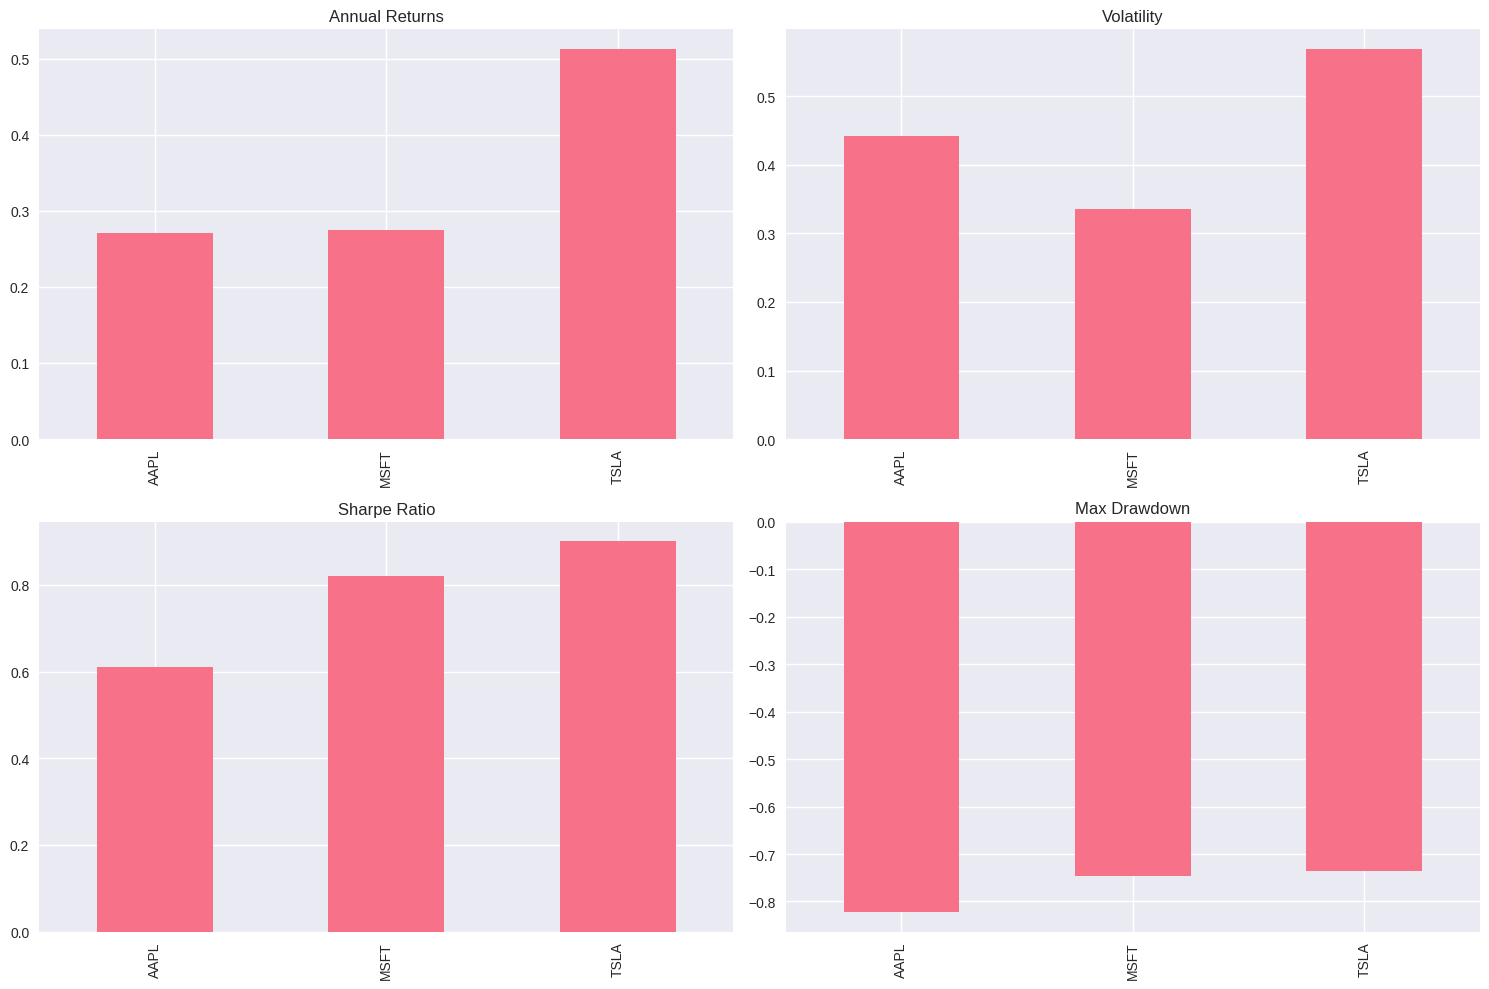

In [69]:
def calculate_metrics(df):
    """Calculate performance metrics"""
    # Ensure 'Close' column exists before calculating daily return
    if 'Close' in df.columns:
        df['Daily_Return'] = df['Close'].pct_change()
    else:
        print("Warning: 'Close' column not found for calculating performance metrics.")
        df['Daily_Return'] = np.nan # Create the column but fill with NaN

    # Calculate metrics only if 'Daily_Return' column was successfully created and has valid data
    if 'Daily_Return' in df.columns and not df['Daily_Return'].isnull().all():
        metrics = {
            'Annual_Return': df['Daily_Return'].mean() * 252,
            'Annual_Volatility': df['Daily_Return'].std() * np.sqrt(252),
            'Sharpe_Ratio': df['Daily_Return'].mean() / df['Daily_Return'].std() * np.sqrt(252) if df['Daily_Return'].std() != 0 else np.nan, # Avoid division by zero
        }
    else:
        print("Warning: Daily returns could not be calculated or are all NaN. Skipping other metrics.")
        metrics = {
            'Annual_Return': np.nan,
            'Annual_Volatility': np.nan,
            'Sharpe_Ratio': np.nan,
        }

    # Max Drawdown calculation - requires 'Close' column
    if 'Close' in df.columns and not df['Close'].isnull().all():
         metrics['Max_Drawdown'] = (df['Close'] / df['Close'].cummax() - 1).min()
    else:
        print("Warning: 'Close' column not found or is all NaN for calculating Max Drawdown.")
        metrics['Max_Drawdown'] = np.nan


    return metrics

# Calculate metrics for all stocks
performance = {}
# Ensure stocks_data is not empty before iterating
if stocks_data:
    performance = {symbol: calculate_metrics(df) for symbol, df in stocks_data.items()}
    performance_df = pd.DataFrame(performance).T

    # Visualize comparison
    # Check if performance_df is not empty before plotting
    if not performance_df.empty:
        fig, ax = plt.subplots(2, 2, figsize=(15, 10))

        # Ensure the columns exist in the performance_df before plotting
        if 'Annual_Return' in performance_df.columns:
            performance_df['Annual_Return'].plot.bar(ax=ax[0,0], title='Annual Returns')
        else:
            print("Warning: 'Annual_Return' column not found in performance_df for plotting.")
            ax[0,0].set_title('Annual Returns (Data Missing)')


        if 'Annual_Volatility' in performance_df.columns:
             performance_df['Annual_Volatility'].plot.bar(ax=ax[0,1], title='Volatility')
        else:
            print("Warning: 'Annual_Volatility' column not found in performance_df for plotting.")
            ax[0,1].set_title('Volatility (Data Missing)')

        if 'Sharpe_Ratio' in performance_df.columns:
             performance_df['Sharpe_Ratio'].plot.bar(ax=ax[1,0], title='Sharpe Ratio')
        else:
            print("Warning: 'Sharpe_Ratio' column not found in performance_df for plotting.")
            ax[1,0].set_title('Sharpe Ratio (Data Missing)')

        if 'Max_Drawdown' in performance_df.columns:
            performance_df['Max_Drawdown'].plot.bar(ax=ax[1,1], title='Max Drawdown')
        else:
            print("Warning: 'Max_Drawdown' column not found in performance_df for plotting.")
            ax[1,1].set_title('Max Drawdown (Data Missing)')


        plt.tight_layout()
        plt.show() # Explicitly show the plot
    else:
        print("Performance DataFrame is empty. No metrics to visualize.")
else:
    print("No stock data loaded. Cannot calculate performance metrics.")

## 7. Correlation Analysis
Analyze how stocks move relative to each other

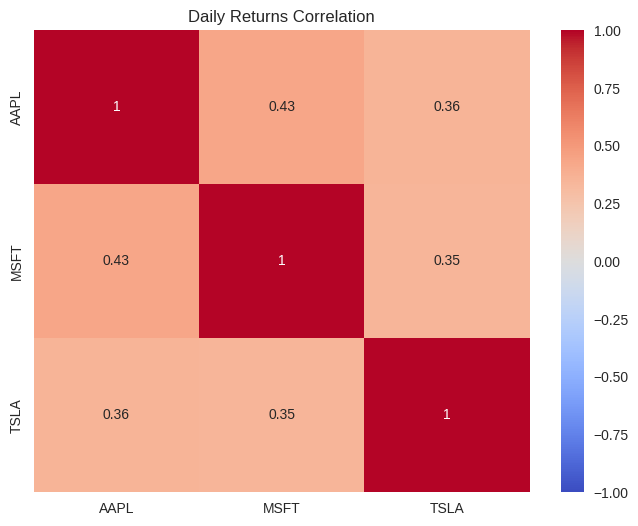

In [70]:
# Create correlation matrix of daily returns
# Ensure stocks_data is not empty before proceeding
if stocks_data:
    # Ensure each DataFrame in stocks_data has a 'Daily_Return' column
    # This column is created in calculate_metrics, but add a check here just in case.
    returns_data = {}
    for symbol, df in stocks_data.items():
        if 'Daily_Return' in df.columns:
            returns_data[symbol] = df['Daily_Return']
        else:
            print(f"Warning: 'Daily_Return' column not found for {symbol}. Skipping correlation for this stock.")

    if returns_data: # Check if there's any data to build the DataFrame
        returns_df = pd.DataFrame(returns_data).corr()

        # Plot heatmap
        plt.figure(figsize=(8,6))
        sns.heatmap(returns_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Daily Returns Correlation');
        plt.show() # Explicitly show the plot
    else:
        print("No stock data with 'Daily_Return' column available for correlation analysis.")
else:
    print("No stock data loaded. Cannot perform correlation analysis.")